In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="6" color="red"><b>ch4. 머신러닝 모형 최적화</b></font>
# 1절. 변수 선택과 차원 축소
## 1-1 변수선택과 차원축소
- 종속변수에 영향을 주는 변수들을 찾아 학습에 사용할 독립변수의 수를 줄임
 (어떻게 하면 score를 높일 수 있을지?)
- 과적합과 변수들 사이의 다중공선성(변수들간 강한 상관관계)을 줄일 수 있음
 * 회귀계수 해석이 어려워짐. 모델 예측력이 좋아도 해석력이 떨어짐(어떤 변수가 제일 큰 요인인지 잘), p값이
나 유의성 검정이 왜곡될 수 있음
- 모형의 학습 시간을 줄일 수 있음
- 주성분분석, 상관분석, **분류모형의 feature_importance_, 예측 모형의 coef_**
- SelectKBest : 가장 높은 score에 따라 K개의 특징을 선택
## 1-2 주성분분석(PCA, Principal Component Anaysis)
- 주성분분석은 변수 선택 및 차원축소 방법(기존의 모든 변수를 조합하여 새로운 변수로 만듦) 으로 널리 사용
- 주성분 분석은 상관관계가 있는 변수들을 선형결합해서 **분산이 극대화된 상관관계가 없는 새로운 변수(주성분)
들로 축약**하는 것
- 주성분 분석은 사실 선형대수학이라기보다는 선형대수학의 활용적인 측면이 강하며 영상인식, 통계 데이터분석
(주성분 찾기), 데이터 압축, 노이즈제거 등 여러 분야에 사용
- 영상처리에서 많이 활용 : 여러개의 영상 중 대표 이미지를 찾을 때 활용

In [5]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris_X, iris_y = iris.iloc[:,:-1], iris.species
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2) # n_component : 주성분 갯수
# pca.fit(iris_X)
# pca.transform(iris_X)
iris_pca = pca.fit_transform(iris_X)
iris_pca[:3] # 뽑혀진 주성분 2개

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943]])

In [12]:
import pandas as pd
pd.DataFrame(iris_pca, columns=['pca1','pca2']).corr() # 주성분끼리의 상관관계

,pca1,pca2
pca1,1.000000e+00,3.722081e-16
pca2,3.722081e-16,1.000000e+00


In [13]:
# 설명분산 : 각 주성분이 데이터 분산을 잘 표현하는지(정보량). 값이 클수록 더 중요한 주성분
pca.explained_variance_

array([4.22824171, 0.24267075])

In [14]:
# 설명정도 : 0~1 사이의 비율로 조정된 값
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

In [15]:
pca.components_
# 각 주성분의 계수 : 각 주성분이 원래 특성들과 어떤 관계가 있는지 나타내는 가중치
# pca1 = (0.36138659*sepal_length) + (-0.08452251*sepal_width) + (0.85667061*petal_length) + (0.3582892*petal_width)
# pca2 = (0.65658877*sepal_length) + ~

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

In [16]:
iris_X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 1-3 상관관계 확인
- 각 변수들끼리 상관관계를 확인하고 시각화해서 종속변수와 상관관계가 높은 변수들만 선택

In [17]:
import pandas as pd
# redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine = pd.read_csv('data/winequality-red.csv', delimiter=';')
redwine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


cmap의 종류 : https://jrc-park.tistory.com/155
- http://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap
- http://seaborn.pydata.org/examples/many_pairwise_correlations.html

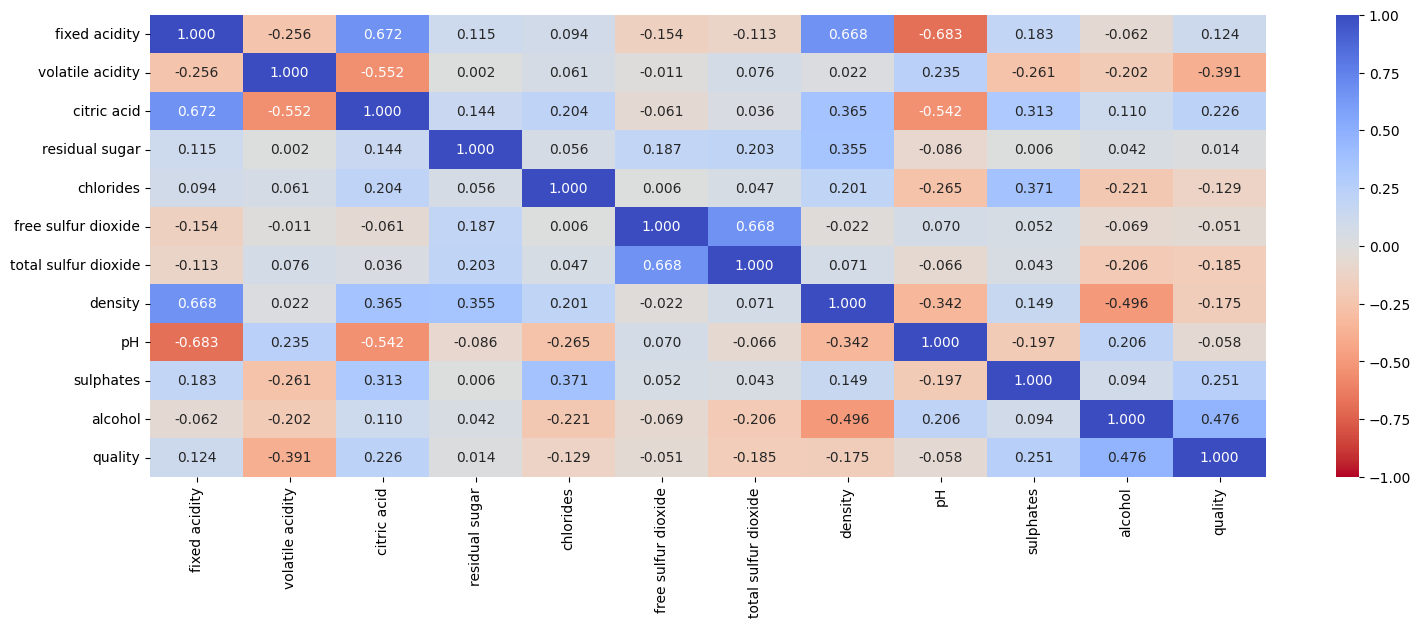

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(18,6))
corr = redwine.corr()
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.show()

In [28]:
import numpy as np
mask = np.tril(np.ones_like(corr)) # 대각선 포함하여 아래가 1
mask = np.tril(np.ones_like(corr), k=-1) # 대각선 제외 아래가 1
mask = np.triu(np.ones_like(corr)) # 대각선 포함하여 위가 1
mask = np.triu(np.ones_like(corr), k=1) # 대각선 제외 위가 1
mask

array([[0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

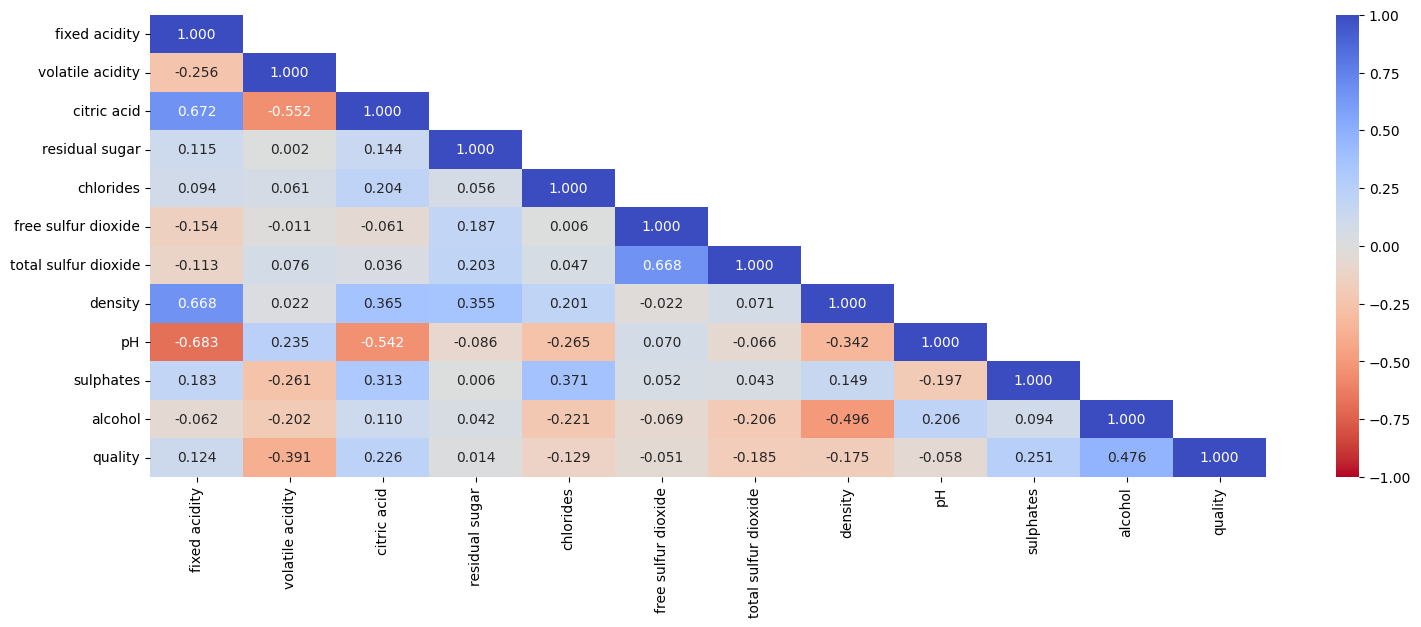

In [29]:
plt.figure(figsize=(18,6))
corr = redwine.corr()
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r', mask = mask)
plt.show()

## 1-4 분류모형의 Feature Importance
- 분류모형의 feature_importance_ 속성 : 각 독립변수들이 종속변수에 영향을 주는 정도
- DecisionTreeClassifier, RandomForestClassifer, GradentBootingClassifier..(tree 계열)
- LogisticRegression, SVC, MLPclassifier등은 feature_importance_속성없음

In [69]:
from sklearn.model_selection import train_test_split
X = redwine.iloc[:,:-1]#.values # numpy 배열로
y = redwine.iloc[:,-1]#.to_numpy()

train_X, test_X, train_y, test_y = train_test_split(X,y, test_size=0.3, stratify= y)
train_X.shape, test_X.shape, train_y.shape, test_y.shape

((1119, 11), (480, 11), (1119,), (480,))

In [70]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10, # 트리의 갯수 10
                                  random_state=10)
rf_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [71]:
rf_model.feature_importances_ # 종속변수에 영향을 주는 정도

array([0.08286232, 0.09974218, 0.07653572, 0.0729905 , 0.0784127 ,
       0.07457935, 0.10826564, 0.08283849, 0.06123036, 0.1095246 ,
       0.15301815])

In [72]:
feature = pd.DataFrame(np.c_[X.columns, rf_model.feature_importances_], columns=['feature', 'importance'])
feature['importance'].sum()

1.0

In [73]:
feature.sort_values(by='importance', ascending=False, inplace=True)
feature.reset_index(drop=True, inplace=True)
feature.set_index(drop=True, keys='feature')

,importance
feature,
alcohol,0.153018
sulphates,0.109525
total sulfur dioxide,0.108266
volatile acidity,0.099742
fixed acidity,0.082862
density,0.082838
chlorides,0.078413
citric acid,0.076536
free sulfur dioxide,0.074579


### feature_importance_를 이용하여 변수 중요도 시각화

<BarContainer object of 11 artists>

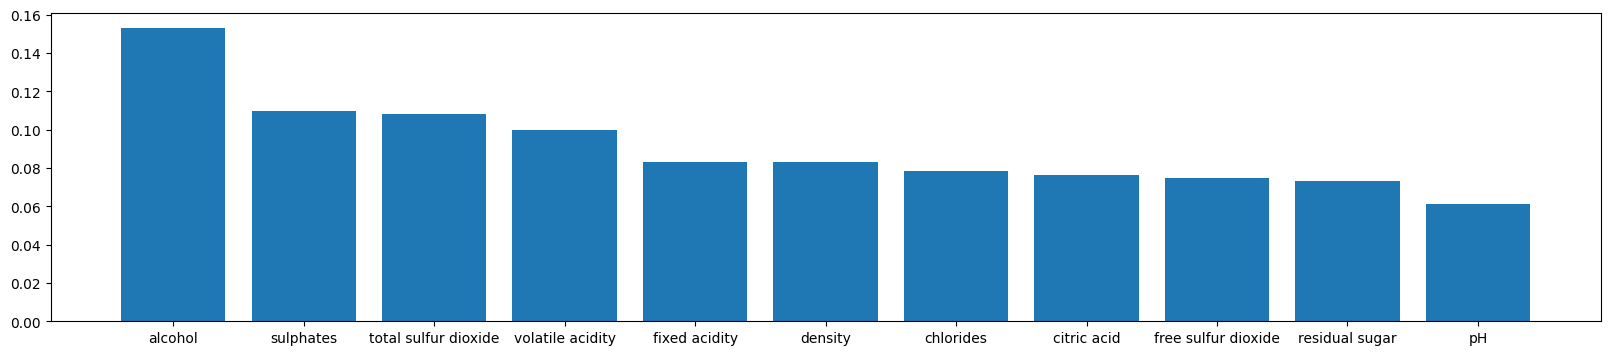

In [74]:
# feature를 시각화
plt.figure(figsize=(20,4))
plt.bar(feature.feature, feature.importance)

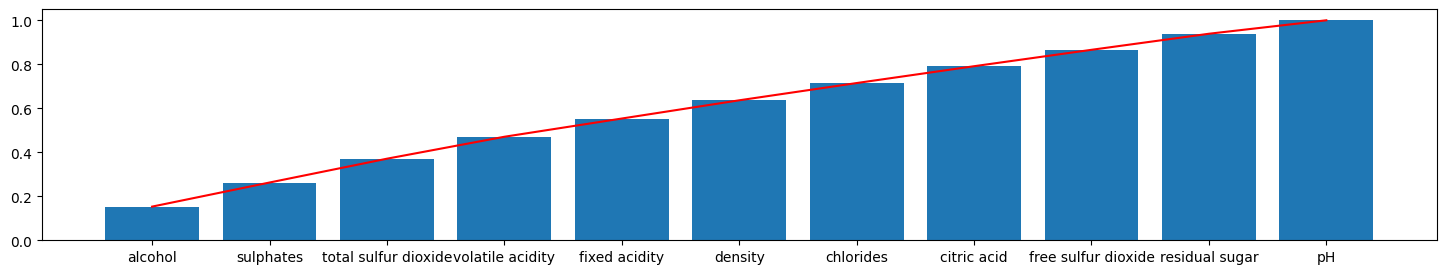

In [84]:
y_stack = np.cumsum(feature.importance)
plt.figure(figsize=(18,3))
plt.bar(feature.feature, y_stack)
plt.plot(feature.feature, y_stack, color='red')
plt.show()

0     0.153018
1     0.262543
2     0.370808
3     0.470551
4     0.553413
5     0.636251
6     0.714664
7       0.7912
8     0.865779
9      0.93877
10         1.0
Name: importance, dtype: object

### RFE(Recursive Feature Elimination) 방식
- RFE를 이용하면 중요도에 따라 증요도가 낮은 변수부터 하나씩 제거해 나가면서 최종적으로 선택한 변수를 찾음

In [86]:
from sklearn.feature_selection import RFE
rfe_model = RFE( # 학습 유무에 관계없이 재학습함
                rf_model,
                n_features_to_select=5
)
rfe_model.fit(train_X,train_y)
rfe_model.get_support() # 선택된 변수(True)인지 제거된 변수(False)인지 여부

array([False,  True, False, False, False, False,  True,  True, False,
        True,  True])

In [90]:
feature_rfe = pd.DataFrame(np.c_[X.columns, rfe_model.get_support()],
                          columns=['feature', 'selected'])
feature_rfe[feature_rfe.selected==True]

,feature,selected
1,volatile acidity,True
6,total sulfur dioxide,True
7,density,True
9,sulphates,True
10,alcohol,True


## 1-5 SelectKBest
- 가장 높은 score에 따라 k개 특정변수 선택

In [98]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, f_classif, chi2
# f_classif : ANNOVA F검정 - 독립변수가 연속형(그룹간 차이가 유의미한지)
# chi2      : 카이제곱통계량 검정 - 독립변수가 범주형(타겟변수도 범주형) 또는 양의 실수
X, y = load_iris(return_X_y=True, as_frame=False)
X.shape, y.shape, y
X_new = SelectKBest(f_classif,k=1).fit_transform(X,y)

In [99]:
X_new[:3]

array([[1.4],
       [1.4],
       [1.3]])

In [100]:
X[:3]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [101]:
load_iris()

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

# 2절 파라미터 탐색
- 하이퍼파라미터(모델의 성능에 영향을 미칠 수 있는 사용자가 직접 설정하는 파라미터)
- 어떤 파라미터를 사용하는게 최적의 결과를 낼지 탐색
- sklearn패키지의 하이퍼 파라미터 튜닝 도구
    * validation_curve() : 단일 하이퍼 파라미터 최적화 함수
    * GridSearchCV : 복수 하이퍼파라미터 최적화 클래스
## 2-1 validation_curve
    - 모형, X, y, param_name(파라미터이름), param_range(파라미터값list), 교차검증, scoring 기준

In [152]:
# 데이터 
from sklearn.datasets import load_digits
digits = load_digits()
# digits.data 1794 X 64 크기의 배열
# digits.target : 1797 크기의 배열 (0~9중 하나)
# digits.images.shape : 1797 X 8 X 8 크기의 배열 (이미지 형태)
X, y = digits.data, digits.target
X.shape, y.shape

((1797, 64), (1797,))

In [153]:
X[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

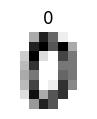

In [154]:
import matplotlib.pyplot as plt
plt.figure(figsize=(1,1))
plt.imshow(X[0].reshape(8,8), cmap='gray_r')
plt.axis('off')
plt.title(y[0])
plt.show()

In [155]:
from sklearn.svm import SVC
model = SVC(probability= True).fit(X,y) # 기본 파라미터로 모형 생성

In [156]:
test_x = X[0].reshape(1, -1)
print('예측 :', model.predict(test_x), ', 실제:', y[0])

예측 : [0] , 실제: 0


In [157]:
prob = model.predict_proba(test_x)[0]
classes = model.classes_
# print('분류 :', classes)
# print('확률 :', prob)
for c, p in zip(classes, prob):
    print('{}일 확률 : {:.3f}%'.format(c,p*100))

0일 확률 : 99.102%
1일 확률 : 0.021%
2일 확률 : 0.047%
3일 확률 : 0.094%
4일 확률 : 0.059%
5일 확률 : 0.146%
6일 확률 : 0.073%
7일 확률 : 0.092%
8일 확률 : 0.075%
9일 확률 : 0.292%


In [158]:
# 파라미터 탐색 전 score(accuracy)
model.score(X,y)

0.996661101836394

In [159]:
# SVC()모형의 최적의 gamma값 탐색
param_range= np.logspace(-6,-1,10) # gamma값의 후보군 ㅑ
param_range

array([1.00000000e-06, 3.59381366e-06, 1.29154967e-05, 4.64158883e-05,
       1.66810054e-04, 5.99484250e-04, 2.15443469e-03, 7.74263683e-03,
       2.78255940e-02, 1.00000000e-01])

In [160]:
%%time
from sklearn.model_selection import validation_curve
train_score, test_score = validation_curve(
        SVC(), # 예측모형
        X,y,
        param_name="gamma", # gamma가 크면 결정경제가 복잡. overfitting위험
        param_range=param_range,
        cv=10, # 교차검증
        scoring='accuracy', # balanced_accuracy(불균형을 고려한 정확도)
        n_jobs=-1 # 모든 코어
)

CPU times: total: 312 ms
Wall time: 9.8 s


In [128]:
train_score

array([[0.10204082, 0.10204082, 0.10204082, 0.10204082, 0.10204082,
        0.10204082, 0.10204082, 0.28615575, 0.19159456, 0.19159456],
       [0.71923315, 0.70995671, 0.72108844, 0.716141  , 0.71552257,
        0.71243043, 0.70810142, 0.72435105, 0.73918418, 0.73856613],
       [0.93753865, 0.93444651, 0.93320965, 0.93135436, 0.93692022,
        0.92888064, 0.93382808, 0.93201483, 0.94313968, 0.93263288],
       [0.96846011, 0.96969697, 0.96722325, 0.97217069, 0.96846011,
        0.96722325, 0.96846011, 0.96538937, 0.97342398, 0.97342398],
       [0.98824985, 0.98577613, 0.9894867 , 0.98763142, 0.98639456,
        0.98824985, 0.98824985, 0.98702101, 0.98825711, 0.98825711],
       [0.99814471, 0.99690785, 0.99814471, 0.99752628, 0.99690785,
        0.99814471, 0.99814471, 0.99814586, 0.99814586, 0.99876391],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.       

In [130]:
train_score.shape, test_score.shape

((10, 10), (10, 10))

In [129]:
test_score

array([[0.1       , 0.1       , 0.1       , 0.1       , 0.1       ,
        0.1       , 0.1       , 0.29608939, 0.19553073, 0.19553073],
       [0.67777778, 0.74444444, 0.7       , 0.66666667, 0.73333333,
        0.67222222, 0.72222222, 0.70949721, 0.67597765, 0.73743017],
       [0.87777778, 0.95      , 0.90555556, 0.86666667, 0.92222222,
        0.91666667, 0.96666667, 0.93854749, 0.83240223, 0.91061453],
       [0.92222222, 0.96666667, 0.95      , 0.91111111, 0.95      ,
        0.98333333, 0.97777778, 0.96648045, 0.87709497, 0.92178771],
       [0.93888889, 0.97222222, 0.93333333, 0.95      , 0.97222222,
        0.98888889, 0.98333333, 0.99441341, 0.91061453, 0.94413408],
       [0.95555556, 1.        , 0.93333333, 0.96666667, 0.98888889,
        0.98888889, 0.99444444, 0.99441341, 0.96089385, 0.96648045],
       [0.93333333, 0.98888889, 0.95555556, 0.96666667, 0.98333333,
        0.98888889, 0.99444444, 0.99441341, 0.97765363, 0.96648045],
       [0.77777778, 0.89444444, 0.7611111

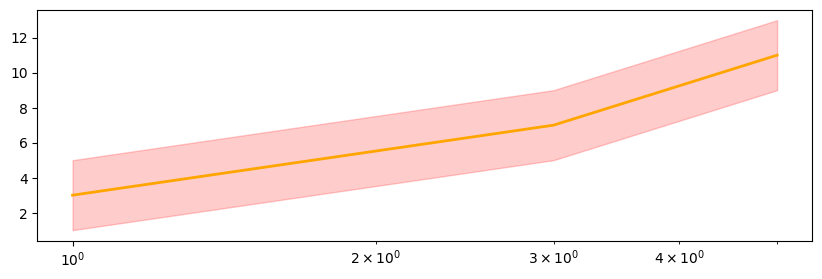

In [147]:
a = np.array([1, 3, 5]) # 10의 1승, 10의 3승, 10의 5승
b = np.array([3, 7, 11]) # 3, 7, 11
plt.figure(figsize=(10,3))
plt.semilogx(x,y, color= 'orange', lw=2)
plt.fill_between(x,y-2,y+2, color='red', alpha=0.2)

In [148]:
train_score_mean = np.mean(train_score, axis=1) #train 평균
train_score_std = np.std(train_score, axis=1) #train 표준편차
test_score_mean = test_score.mean(axis=1) #test 평균
test_score_std = test_score.std(axis=1) #test 표줒편차

In [149]:
train_score_mean

array([0.13836306, 0.72045751, 0.93439655, 0.96939318, 0.98775736,
       0.99789765, 1.        , 1.        , 1.        , 1.        ])

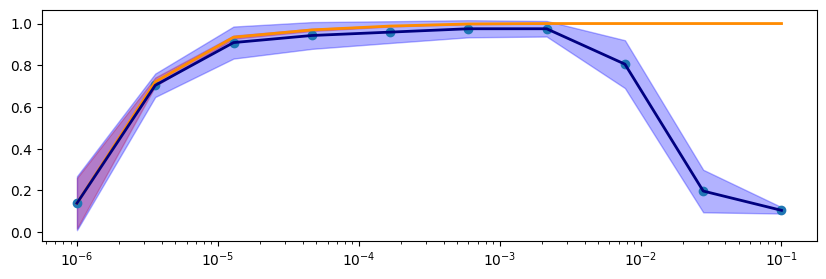

In [150]:
plt.figure(figsize=(10,3))
plt.semilogx(param_range, train_score_mean, color='darkorange', lw=2)
plt.fill_between(param_range,
                train_score_mean-train_score_std*2,
                train_score_mean+train_score_std*2,
                alpha=0.3, color='red')

plt.semilogx(param_range, test_score_mean, color='navy', lw=2)
plt.fill_between(param_range,
                test_score_mean-test_score_std*2,
                test_score_mean+test_score_std*2,
                alpha=0.3, color='blue')
plt.scatter(param_range, test_score_mean)
plt.show()

In [144]:
test_score_mean.argmax()

array([0.13871508, 0.70395717, 0.90871198, 0.94264742, 0.95880509,
       0.97495655, 0.97496586, 0.80522036, 0.19709497, 0.10463687])

In [161]:
# 최적의 gamma
gamma = param_range[test_score_mean.argmax()]
gamma

0.0021544346900318843

In [162]:
model = SVC(gamma=gamma).fit(X,y)

In [163]:
model.score(X,y)

1.0

## 2-2 GridSearchCV
- 복수 하이퍼파라미터 최적화 클래스
- 모형 클래스를 가지고 있음
- fit()/predict()/predict_proba()/predict_log_proba()

In [165]:
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine_X = redwine.iloc[:,:-1]
redwine_y = redwine.iloc[:,-1]
redwine_X.shape, redwine_y.shape

((1599, 11), (1599,))

In [166]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.svm import SVC

In [169]:
%%time
# 가장 평가 점수가 높은 독립변수 ?개 선택, SVC()모형의 최적의 C=?
selection = SelectKBest(k=1) # 가장 평가 점수가 높은 k개를 찾음
svc = SVC(kernel='linear') # 직선으로 나누는 가장 단순한 decision_function
pipeline = Pipeline([('select', selection),('svc', svc)])
param_grid = dict(select__k = [5,6,7,8,9,10,11],
                 svc__C=[0.1, 1, 10])
grid_search = GridSearchCV(pipeline,
                          param_grid=param_grid, # 파라미터들
                          cv=2, # 교차검증 k-fold cross validation
                          verbose=2,
                          n_jobs=-1)
grid_search.fit(redwine_X, redwine_y)

Fitting 2 folds for each of 21 candidates, totalling 42 fits
CPU times: total: 13.4 s
Wall time: 1min 30s


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('select', SelectKBest(k=1)),
                                       ('svc', SVC(kernel='linear'))]),
             n_jobs=-1,
             param_grid={'select__k': [5, 6, 7, 8, 9, 10, 11],
                         'svc__C': [0.1, 1, 10]},
             verbose=2)

In [170]:
print(grid_search.best_estimator_) # 가장 높은 점수를 낸 파라미터 모형

Pipeline(steps=[('select', SelectKBest(k=9)),
                ('svc', SVC(C=1, kernel='linear'))])


In [171]:
print(grid_search.best_params_) # 최적의 파라미터 정보

{'select__k': 9, 'svc__C': 1}


In [172]:
model = grid_search.best_estimator_
model.predict(redwine_X)

array([5, 5, 5, ..., 6, 5, 6], dtype=int64)

In [174]:
# 최적의 k값과 C값의 model
model.score(redwine_X, redwine_y)

0.5872420262664165

In [175]:
# 기본 SCV model
model = SVC().fit(redwine_X,redwine_y)
model.score(redwine_X, redwine_y)

0.5103189493433395

# 3절 자료 불균형 처리
- 단순 오버/언더 샘플링
- 단, 단순 오버 샘플링시 소스의 데이터를 복사하면 그 데이터들에 의해 과적합 생길 수 있음
- SMOTE 라이브러리를 이용한 오버샘플링
## 3-1. SMOTE를 이용한 오버샘플링

In [183]:
# 데이터 (99% vs 1%)
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000,
                           n_features=10,   # 독립변수 갯수 
                           n_informative=5, # 종속변수에 영향을 주는 갯수
                           n_redundant=0,
                           n_clusters_per_class=1, # 클래스당 서브 클러스터 수
                           n_classes=2,
                           weights =  [0.99,0.01], # 각 클래스에 할당된 표본 확률
                           random_state=42
                          )
X.shape, y.shape, y.sum()

((10000, 10), (10000,), 140)

In [184]:
# train-test 셋 분리 => SMOTE(train데이터) => 모델 fit(train데이터) => score(test데이터)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                   test_size=0.3,
                                                   stratify=y,
                                                   random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7000, 10), (7000,), (3000, 10), (3000,))

In [187]:
print(y_train.mean()) # 1이 1.4%
pd.Series(y_train).value_counts()

0.014


0    6902
1      98
dtype: int64

In [193]:
# SMOTE(train 데이터)
from imblearn.over_sampling import SMOTE
# sm = SMOTE(sampling_strategy={0:6902, 1:600})
sm = SMOTE()
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

In [195]:
pd.Series(y_resampled).value_counts()

0    6902
1    6902
dtype: int64

## 3-2. 가중치 제어 모형
- 자료 불균형 처리의 또 다른 방법
- 모델의 데이터 따른 가중치 부여 방법

In [196]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100,
                                  class_weight={0:1,1:1.5}, # 가중치 부여
                                  random_state=42
                                 )
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 1.5}, random_state=42)

# 4절 앙상블 모형
- 목적 : 여러개 분류 모델을 하나느이 통합 분류모델로 연결하여 개별 분류모델보다 더 좋은 성능 달성
- 방법 : 
    * 배깅 (bagging)   : 분류를 잘하는 모델에 가중치 (병렬작업) ex. RandomForest
    * 부스팅(boosting) : 분류가 되지 않은 데이터에 가중치 (순차작업) ex.XGBoost, LGBM, AdaBoost - 불균형데이터
    * 투표(Voting)     : 여러개 모델의 다수결 투표 

cf. 베깅 알고리즘시 0.632 규칙 : 복원추출시 대체로 63.2% 내외 추출

In [200]:
np.random.choice(10, 10, replace = True) # 복원추출로 10 미만의 수를 10개 추출

array([7, 7, 9, 5, 3, 4, 3, 3, 6, 6])

In [218]:
# 10 미만의 수 10개 복원 추출할 겨웅 뽑히는 수의 갯수
len(set(np.random.choice(10, 10, replace = True)))

7

In [224]:
# 1000 미만의 수 1000개 복원 추출할 겨웅 뽑히는 수의 갯수
len(set(np.random.choice(1000, 1000, replace = True)))

634

In [255]:
# n 미만의 수 n개 복원 추출할 겨웅 뽑히는 데이터 %
n = 100000
len(set(np.random.choice(n, n, replace = True)))/n 

0.63168

In [256]:
# 데이터
X,y = make_classification(n_samples=10000,
                          n_features=10,
                          n_informative=5,
                          n_redundant=0,
                          n_clusters_per_class=1,
                          n_classes=2,
                          weights=[0.9,0.1],
                          random_state=42)

In [257]:
train_X, test_X, train_y, test_y = train_test_split(X,y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=42)
sm = SMOTE()
resampled_X, resampled_y = sm.fit_resample(train_X, train_y)
resampled_X.shape, resampled_y.shape

((12556, 10), (12556,))

In [262]:
from sklearn.metrics import precision_score, recall_score, f1_score
def model_measure(model, train_X = resampled_X, train_y = resampled_y, test_X = test_X, test_y= test_y):
    model.fit(train_X,train_y)
    accuracy = model.score(test_X, test_y)
    hat_y = model.predict(test_X)
    precision = precision_score(test_y, hat_y)
    recall = recall_score(test_y, hat_y)
    f1 = f1_score(test_y, hat_y)
    print(f"정확도 :{accuracy:.4f}, precision:{precision:.4f}, recall:{recall:.4f}, f1:{f1:.4f}")

## 4-1 배깅
- RandomForestClassifier, BaggingClassifier

In [263]:
# 배깅
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model_measure(model)

정확도 :0.9827, precision:0.9356, recall:0.8932, f1:0.9139


In [264]:
from sklearn.ensemble import BaggingClassifier
model_measure(BaggingClassifier(n_estimators=500,bootstrap=True)) # 복원추출

정확도 :0.9773, precision:0.8925, recall:0.8867, f1:0.8896


## 4-2 부스팅
- AdaBoost, XGB, LightGBM, CatBoost

In [265]:
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBRFClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [266]:
model_measure(AdaBoostClassifier())

정확도 :0.9630, precision:0.7690, recall:0.9159, f1:0.8360


In [268]:
model_measure(XGBRFClassifier())

정확도 :0.9633, precision:0.7696, recall:0.9191, f1:0.8378


In [269]:
model_measure(LGBMClassifier(force_col_wise=True))

[LightGBM] [Info] Number of positive: 6278, number of negative: 6278
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 12556, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
정확도 :0.9850, precision:0.9430, recall:0.9094, f1:0.9259


In [270]:
model_measure(CatBoostClassifier())

Learning rate set to 0.030349
0:	learn: 0.6503736	total: 163ms	remaining: 2m 42s
1:	learn: 0.6128611	total: 170ms	remaining: 1m 24s
2:	learn: 0.5723032	total: 176ms	remaining: 58.6s
3:	learn: 0.5371659	total: 183ms	remaining: 45.6s
4:	learn: 0.5056908	total: 189ms	remaining: 37.6s
5:	learn: 0.4723326	total: 195ms	remaining: 32.2s
6:	learn: 0.4441513	total: 201ms	remaining: 28.5s
7:	learn: 0.4183814	total: 208ms	remaining: 25.8s
8:	learn: 0.3994696	total: 216ms	remaining: 23.7s
9:	learn: 0.3813430	total: 222ms	remaining: 21.9s
10:	learn: 0.3611594	total: 227ms	remaining: 20.4s
11:	learn: 0.3432293	total: 233ms	remaining: 19.2s
12:	learn: 0.3291118	total: 239ms	remaining: 18.2s
13:	learn: 0.3156720	total: 245ms	remaining: 17.3s
14:	learn: 0.3029626	total: 251ms	remaining: 16.5s
15:	learn: 0.2891848	total: 257ms	remaining: 15.8s
16:	learn: 0.2801615	total: 263ms	remaining: 15.2s
17:	learn: 0.2690861	total: 269ms	remaining: 14.7s
18:	learn: 0.2597826	total: 275ms	remaining: 14.2s
19:	learn

167:	learn: 0.0627111	total: 1.23s	remaining: 6.12s
168:	learn: 0.0625784	total: 1.24s	remaining: 6.11s
169:	learn: 0.0623025	total: 1.25s	remaining: 6.09s
170:	learn: 0.0621360	total: 1.27s	remaining: 6.16s
171:	learn: 0.0619926	total: 1.28s	remaining: 6.15s
172:	learn: 0.0616722	total: 1.28s	remaining: 6.14s
173:	learn: 0.0614400	total: 1.29s	remaining: 6.13s
174:	learn: 0.0612398	total: 1.3s	remaining: 6.11s
175:	learn: 0.0610112	total: 1.3s	remaining: 6.1s
176:	learn: 0.0606396	total: 1.31s	remaining: 6.09s
177:	learn: 0.0604669	total: 1.31s	remaining: 6.08s
178:	learn: 0.0602384	total: 1.32s	remaining: 6.06s
179:	learn: 0.0599705	total: 1.33s	remaining: 6.05s
180:	learn: 0.0598043	total: 1.33s	remaining: 6.04s
181:	learn: 0.0594993	total: 1.34s	remaining: 6.03s
182:	learn: 0.0593113	total: 1.35s	remaining: 6.01s
183:	learn: 0.0590280	total: 1.35s	remaining: 6s
184:	learn: 0.0588470	total: 1.36s	remaining: 5.99s
185:	learn: 0.0586547	total: 1.36s	remaining: 5.98s
186:	learn: 0.0584

355:	learn: 0.0339605	total: 2.46s	remaining: 4.46s
356:	learn: 0.0338447	total: 2.47s	remaining: 4.45s
357:	learn: 0.0337470	total: 2.48s	remaining: 4.44s
358:	learn: 0.0336772	total: 2.48s	remaining: 4.44s
359:	learn: 0.0335197	total: 2.49s	remaining: 4.43s
360:	learn: 0.0334436	total: 2.5s	remaining: 4.42s
361:	learn: 0.0333512	total: 2.51s	remaining: 4.42s
362:	learn: 0.0332555	total: 2.51s	remaining: 4.41s
363:	learn: 0.0331665	total: 2.52s	remaining: 4.4s
364:	learn: 0.0331208	total: 2.53s	remaining: 4.39s
365:	learn: 0.0330239	total: 2.53s	remaining: 4.39s
366:	learn: 0.0329360	total: 2.54s	remaining: 4.38s
367:	learn: 0.0328475	total: 2.55s	remaining: 4.37s
368:	learn: 0.0328051	total: 2.55s	remaining: 4.36s
369:	learn: 0.0327179	total: 2.56s	remaining: 4.36s
370:	learn: 0.0326357	total: 2.56s	remaining: 4.35s
371:	learn: 0.0325765	total: 2.57s	remaining: 4.34s
372:	learn: 0.0325206	total: 2.58s	remaining: 4.33s
373:	learn: 0.0324714	total: 2.58s	remaining: 4.32s
374:	learn: 0.

516:	learn: 0.0216663	total: 3.5s	remaining: 3.27s
517:	learn: 0.0216494	total: 3.5s	remaining: 3.26s
518:	learn: 0.0216103	total: 3.51s	remaining: 3.25s
519:	learn: 0.0215816	total: 3.51s	remaining: 3.24s
520:	learn: 0.0215106	total: 3.52s	remaining: 3.24s
521:	learn: 0.0214359	total: 3.53s	remaining: 3.23s
522:	learn: 0.0213913	total: 3.53s	remaining: 3.22s
523:	learn: 0.0212901	total: 3.54s	remaining: 3.22s
524:	learn: 0.0211802	total: 3.55s	remaining: 3.21s
525:	learn: 0.0211657	total: 3.55s	remaining: 3.2s
526:	learn: 0.0211264	total: 3.56s	remaining: 3.19s
527:	learn: 0.0210852	total: 3.56s	remaining: 3.19s
528:	learn: 0.0210233	total: 3.57s	remaining: 3.18s
529:	learn: 0.0209902	total: 3.58s	remaining: 3.17s
530:	learn: 0.0209531	total: 3.58s	remaining: 3.17s
531:	learn: 0.0208973	total: 3.59s	remaining: 3.16s
532:	learn: 0.0208381	total: 3.6s	remaining: 3.15s
533:	learn: 0.0207736	total: 3.6s	remaining: 3.14s
534:	learn: 0.0206861	total: 3.61s	remaining: 3.14s
535:	learn: 0.020

679:	learn: 0.0148821	total: 4.52s	remaining: 2.13s
680:	learn: 0.0148455	total: 4.52s	remaining: 2.12s
681:	learn: 0.0148076	total: 4.53s	remaining: 2.11s
682:	learn: 0.0147729	total: 4.54s	remaining: 2.1s
683:	learn: 0.0147230	total: 4.54s	remaining: 2.1s
684:	learn: 0.0146711	total: 4.55s	remaining: 2.09s
685:	learn: 0.0146464	total: 4.55s	remaining: 2.08s
686:	learn: 0.0145827	total: 4.56s	remaining: 2.08s
687:	learn: 0.0145611	total: 4.57s	remaining: 2.07s
688:	learn: 0.0145410	total: 4.57s	remaining: 2.06s
689:	learn: 0.0145260	total: 4.58s	remaining: 2.06s
690:	learn: 0.0145046	total: 4.58s	remaining: 2.05s
691:	learn: 0.0144662	total: 4.59s	remaining: 2.04s
692:	learn: 0.0144020	total: 4.6s	remaining: 2.04s
693:	learn: 0.0143957	total: 4.6s	remaining: 2.03s
694:	learn: 0.0143830	total: 4.61s	remaining: 2.02s
695:	learn: 0.0143493	total: 4.62s	remaining: 2.02s
696:	learn: 0.0143270	total: 4.62s	remaining: 2.01s
697:	learn: 0.0143024	total: 4.63s	remaining: 2s
698:	learn: 0.01425

845:	learn: 0.0105638	total: 5.54s	remaining: 1.01s
846:	learn: 0.0105537	total: 5.55s	remaining: 1s
847:	learn: 0.0105443	total: 5.55s	remaining: 995ms
848:	learn: 0.0105238	total: 5.56s	remaining: 989ms
849:	learn: 0.0104913	total: 5.57s	remaining: 982ms
850:	learn: 0.0104882	total: 5.57s	remaining: 976ms
851:	learn: 0.0104645	total: 5.58s	remaining: 969ms
852:	learn: 0.0104387	total: 5.59s	remaining: 963ms
853:	learn: 0.0104184	total: 5.59s	remaining: 956ms
854:	learn: 0.0103946	total: 5.6s	remaining: 950ms
855:	learn: 0.0103689	total: 5.61s	remaining: 943ms
856:	learn: 0.0103492	total: 5.61s	remaining: 937ms
857:	learn: 0.0103188	total: 5.62s	remaining: 930ms
858:	learn: 0.0102926	total: 5.63s	remaining: 924ms
859:	learn: 0.0102708	total: 5.63s	remaining: 917ms
860:	learn: 0.0102474	total: 5.64s	remaining: 911ms
861:	learn: 0.0102370	total: 5.65s	remaining: 904ms
862:	learn: 0.0102320	total: 5.65s	remaining: 897ms
863:	learn: 0.0102124	total: 5.66s	remaining: 891ms
864:	learn: 0.01